# Pendulum: PD + LSE vs active LSE

Pipeline:

1. **Collect data** — PD + exploration trajectories (`SimplePendulumDynamics`)
2. **Active LSE** — Alg. 2; LSE updated after each plan/track episode
3. **LSE baseline** at `update_every` steps (mean episode length from active runs)
4. **SME comparison** — exact SME vs roll out SME vs random SME vs recursive template SME vs Fogel–Huang ellipsoid SME
5. **Error vs T** — LSE: $\|\hat\theta - \theta^*\|_2/\|\theta^*\|_2$; SME: $\max_j(\theta_{j,T}^{\max}-\theta_{j,T}^{\min})/\|\theta^*\|_2$
6. **Plots** — LSE curves over `max_time_hor`; SME curves over the samples used
7. **Save results** — persist the data needed to reload and plot directly

Run with working directory `yingying` (this folder is self-contained).


In [1]:
import importlib
import pickle
import time
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from pendulum_dynamics import SimplePendulumDynamics, system_parameters
import pendulum_dynamics_active_explore as pdae
import pendulum_RLS as prls
import pendulum_SME_approx as sme_approx
import pendulum_SME_ellipsoid as sme_ellipsoid
import set_membership_lin_prog_pend as sme_pend

importlib.reload(pdae)
importlib.reload(prls)
importlib.reload(sme_approx)
importlib.reload(sme_ellipsoid)
importlib.reload(sme_pend)

from pendulum_dynamics_active_explore import run_active_learning
from lse_pend import theta_star_values
from pendulum_RLS import (
    mean_std_error_curves,
    rls_errors_sequence,
    rls_p_matrix_sequence,
)
from pendulum_SME_approx import (
    run_exact_sme_curves,
    run_template_sme_curves,
    run_roll_out_sme_curves,
    run_random_sme_curves,
)
from pendulum_SME_ellipsoid import run_ellipsoid_sme_curves

np.set_printoptions(precision=4, suppress=True)

m, l, k = system_parameters()
theta_star = theta_star_values(m, l)
print("theta_star =", theta_star)

theta_star = [ 2. 40.]


In [2]:
disturbance = "trunc_guass"
parameter_dist = [0.0, 1, 1]
mult_w = [1, 1]

c_input = "trunc_guass"
parameter_input = [0.0, 1, 1]
mult_u = [1]

n_epoch = 5
n_epoch_sme = 5  # SME uses first n_epoch_sme passive trajectories
n_epoch_a = 5
max_time_hor = int(1e5)    

assert n_epoch_sme <= n_epoch

seeds_u = range(131, 131 + n_epoch)
seeds_w = range(331, 331 + n_epoch)

time_hor_rls_ = list(range(1, max_time_hor + 1))

precision_tol = 1e-4   # 7e-5
w_max = 0.01
sme_min_T = 2

# SME mode: "precision" stops at precision_tol; "horizon" runs through sme_horizon_T.
sme_run_mode = "horizon"
sme_horizon_T = 5e4

# Choose "linprog" for SciPy HiGHS or "gurobi" for Gurobi.
sme_solver = "gurobi"

# Fogel-Huang ellipsoid SME uses Algorithm 2 (minimum trace) from the paper.
sme_ellipsoid_objective = "volume"

# Exact SME is slow because LP constraints grow with T.
# Template SME accepts one or more fixed template sizes m.
sme_template_sides_list = [4, 8]

# Roll out SME uses the latest H strips and accepts only smaller coordinate widths.
sme_roll_out_recent_window = 100

# Random SME samples N past trajectory strips and accepts only smaller coordinate widths.
sme_random_sample_size = 100
sme_random_seed = 0

# LSE still computes P_t so its timing includes uncertainty-matrix setup work.
p_matrix_ridge = 1e-8

bu = 1.0

## 1) Passive: collect PD + exploration trajectories

In [3]:
print("Collecting PD + exploration trajectories...")
Delta_S_list = []
Phi_S_U_list = []
passive_collect_wall_list = []

t_passive_collect = time.perf_counter()
for e in range(n_epoch):
    t_traj_collect = time.perf_counter()
    pend = SimplePendulumDynamics(c_input, disturbance)
    pend.get_trajectory_3(
        [0.0, 0.0],
        max_time_hor,
        seeds_u[e],
        seeds_w[e],
        parameter_input,
        mult_u,
        parameter_dist,
        mult_w,
        bu,
    )
    passive_collect_wall_list.append(time.perf_counter() - t_traj_collect)
    Delta_S_list.append(pend.b_s_list)
    Phi_S_U_list.append(pend.phi_s_u_list)
    print("  trajectory", e + 1, "/", n_epoch)

passive_collect_wall_s = time.perf_counter() - t_passive_collect
print("Done. collection wall time (s):", round(passive_collect_wall_s, 2))

  trajectory 1 / 5
  trajectory 2 / 5
  trajectory 3 / 5
  trajectory 4 / 5
  trajectory 5 / 5
Done. collection wall time (s): 4.09


## 2) Active LSE (Alg. 2)

In [4]:
importlib.reload(pdae)

active_cfg = dict(
    H=10,
    alpha=0.3,
    beta=0.01,
    bu=bu,
    n_plan_samples=5000,
    warmup=30,
    distr=disturbance,
    param_w=tuple(parameter_dist),
    mult_w=tuple(mult_w),
)

print("Running active LSE...")
res_active_list = []
active_collect_wall_list = []

for e in range(n_epoch_a):
    print(f"  active LSE epoch {e + 1} / {n_epoch_a}  (seed_w = {seeds_w[e]})")
    res_e = run_active_learning(
        np.array([0.0, 0.0]),
        m,
        l,
        T_budget=max_time_hor,
        seed_w=seeds_w[e],
        rng=np.random.default_rng(2026 + e),
        **active_cfg,
    )
    res_active_list.append(res_e)
    active_collect_wall_list.append(res_e.collection_wall_s)

    if res_e.planning_failed:
        print("    planning failed:", res_e.planning_fail_message)
    else:
        print(
            "    segments:",
            res_e.n_segments,
            "| RLS updates:",
            res_e.n_rls_updates,
            "| avg steps/update:",
            round(res_e.avg_steps_per_update, 1),
            "| sim steps:",
            res_e.steps,
            "| wall (s):",
            round(res_e.collection_wall_s, 2),
        )

active_collect_wall_s = float(np.sum(active_collect_wall_list))
n_active_ok = sum(not r.planning_failed for r in res_active_list)
print(
    f"Active done: {n_active_ok}/{n_epoch_a} epochs succeeded;"
    f" total collection wall time (s): {active_collect_wall_s:.2f}"
)

Running active LSE...
  active LSE epoch 1 / 5  (seed_w = 331)
    segments: 99970 | RLS updates: 99971 | avg steps/update: 1.0 | sim steps: 100000 | wall (s): 47.88
  active LSE epoch 2 / 5  (seed_w = 332)
    segments: 99970 | RLS updates: 99971 | avg steps/update: 1.0 | sim steps: 100000 | wall (s): 49.49
  active LSE epoch 3 / 5  (seed_w = 333)
    segments: 99970 | RLS updates: 99971 | avg steps/update: 1.0 | sim steps: 100000 | wall (s): 48.02
  active LSE epoch 4 / 5  (seed_w = 334)
    segments: 99970 | RLS updates: 99971 | avg steps/update: 1.0 | sim steps: 100000 | wall (s): 47.22
  active LSE epoch 5 / 5  (seed_w = 335)
    segments: 99970 | RLS updates: 99971 | avg steps/update: 1.0 | sim steps: 100000 | wall (s): 48.41
Active done: 5/5 epochs succeeded; total collection wall time (s): 241.02


In [5]:
from pendulum_dynamics_active_explore import update_every_from_active_results

update_every = update_every_from_active_results(res_active_list)
print(
    f"RLS/SME update cadence: every {update_every} steps "
    f"(~{max_time_hor / update_every:.1f} batch updates per trajectory)"
)


RLS/SME update cadence: every 1 steps (~100000.0 batch updates per trajectory)


## 3) Passive RLS

In [6]:
print(f"Passive RLS (batch update every {update_every} steps)...")

t_passive_rls = time.perf_counter()
passive_rls_err_seqs = []
passive_rls_p_matrix_seqs = []
passive_rls_wall_list = []
for e in range(n_epoch):
    t_traj_rls = time.perf_counter()
    passive_rls_err_seqs.append(
        rls_errors_sequence(
            Delta_S_list[e], Phi_S_U_list[e], theta_star, update_every=update_every
        )
    )
    passive_rls_p_matrix_seqs.append(
        rls_p_matrix_sequence(
            Phi_S_U_list[e],
            ridge=p_matrix_ridge,
            update_every=update_every,
        )
    )
    passive_rls_wall_list.append(time.perf_counter() - t_traj_rls)
mean_err_passive, std_err_passive = mean_std_error_curves(passive_rls_err_seqs)
passive_rls_wall_s = time.perf_counter() - t_passive_rls

print("Passive RLS done. wall (s):", round(passive_rls_wall_s, 2))
print("  final T error (mean):", mean_err_passive[-1])

Passive RLS (batch update every 1 steps)...
Passive RLS done. wall (s): 38.1
  final T error (mean): 7.385636880873636e-05


In [7]:
def _pad_to_horizon(seq, horizon):
    out = np.full(int(horizon), np.nan, dtype=float)
    n = min(len(seq), int(horizon))
    out[:n] = np.asarray(seq, dtype=float)[:n]
    return out


def _nan_mean_std(seqs):
    if not seqs:
        return np.full(max_time_hor, np.nan), np.full(max_time_hor, np.nan)
    stack = np.stack([_pad_to_horizon(s, max_time_hor) for s in seqs], axis=0)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        return np.nanmean(stack, axis=0), np.nanstd(stack, axis=0)


def first_stable_under(curve, tol):
    """First 1-based sample after which the curve stays finite and under tol."""
    values = np.asarray(curve, dtype=float)
    ok = np.isfinite(values) & (values <= tol)
    suffix_ok = np.logical_and.accumulate(ok[::-1])[::-1]
    idx = np.where(suffix_ok)[0]
    return None if idx.size == 0 else int(idx[0]) + 1


def scaled_wall_time(T, total_wall_s, horizon):
    if T is None or horizon <= 0:
        return np.nan
    return float(total_wall_s) * float(T) / float(horizon)


print("Active LSE error decay vs T...")

t_active_rls = time.perf_counter()
active_rls_err_seqs = []
active_rls_p_matrix_seqs = []
active_rls_wall_list = []
for res_e in res_active_list:
    if res_e.planning_failed:
        continue
    t_traj_rls = time.perf_counter()
    active_rls_err_seqs.append(
        rls_errors_sequence(
            res_e.y_delta_omega,
            res_e.psi_rows,
            theta_star,
            update_every=update_every,
        )
    )
    active_rls_p_matrix_seqs.append(
        rls_p_matrix_sequence(
            res_e.psi_rows,
            ridge=p_matrix_ridge,
            update_every=update_every,
        )
    )
    active_rls_wall_list.append(time.perf_counter() - t_traj_rls)

mean_err_active, std_err_active = _nan_mean_std(active_rls_err_seqs)
active_rls_wall_s = time.perf_counter() - t_active_rls

passive_rls_stable_T = first_stable_under(mean_err_passive, precision_tol)
active_rls_stable_T = first_stable_under(mean_err_active, precision_tol)
pd_rls_wall_avg = (passive_collect_wall_s + passive_rls_wall_s) / n_epoch
active_wall_avg = (active_collect_wall_s + active_rls_wall_s) / n_epoch_a
passive_rls_stable_wall_s = scaled_wall_time(
    passive_rls_stable_T, pd_rls_wall_avg, max_time_hor
)
active_rls_stable_wall_s = scaled_wall_time(
    active_rls_stable_T, active_wall_avg, max_time_hor
)

active_finite = mean_err_active[np.isfinite(mean_err_active)]
print("Active LSE error curve done. wall (s):", round(active_rls_wall_s, 2))
print("  final T error (mean):", active_finite[-1] if active_finite.size else np.nan)
print(f"\nStable crossing of {precision_tol:.0e} on mean curves:")
if passive_rls_stable_T is None:
    print("  PD + LSE: not reached")
else:
    print(
        f"  PD + LSE: T = {passive_rls_stable_T}, "
        f"estimated wall = {passive_rls_stable_wall_s:.2f}s"
    )
if active_rls_stable_T is None:
    print("  Active LSE: not reached")
else:
    print(
        f"  Active LSE: T = {active_rls_stable_T}, "
        f"estimated wall = {active_rls_stable_wall_s:.2f}s"
    )

Active LSE error decay vs T...
Active LSE error curve done. wall (s): 40.13
  final T error (mean): 4.749066946041614e-05

Stable crossing of 1e-04 on mean curves:
  PD + LSE: T = 84399, estimated wall = 7.12s
  Active LSE: T = 24152, estimated wall = 13.58s


## 4) Set Membership Estimation (SME)

Exact SME solves LPs with all historical constraints. Roll out SME keeps the latest `sme_roll_out_recent_window` strips and accepts only updates that shrink coordinate width. Random SME samples `sme_random_sample_size` past trajectory strips and uses the same monotone coordinate-width gate. Template SME uses a recursive fixed-direction polytope for each template size in `sme_template_sides_list`. Ellipsoid SME uses the Fogel–Huang minimum-trace update.

In [8]:
sme_horizon_T = 2e4
sme_stop_at_precision = sme_run_mode == "precision"
sme_eval_max_T = max_time_hor if sme_stop_at_precision else min(max_time_hor, sme_horizon_T)
if sme_run_mode not in {"precision", "horizon"}:
    raise ValueError('sme_run_mode must be "precision" or "horizon"')
if sme_solver not in {"linprog", "gurobi"}:
    raise ValueError('sme_solver must be "linprog" or "gurobi"')

sme_run_label = (
    f"width / ||theta*|| <= {precision_tol:.0e}"
    if sme_stop_at_precision
    else f"T = {sme_eval_max_T}"
)

exact_sme_summary = run_exact_sme_curves(
    Delta_S_list,
    Phi_S_U_list,
    n_epoch_sme=n_epoch_sme,
    horizon=sme_eval_max_T,
    print_horizon_label=sme_run_label,
    w_max=w_max,
    min_T=sme_min_T,
    theta_star=theta_star,
    tol=precision_tol,
    update_every=update_every,
    stop_at_tol=sme_stop_at_precision,
    solver="linprog",
)

passive_sme_width_norm_seqs = exact_sme_summary.width_norm_seqs
passive_sme_reach_T = exact_sme_summary.reach_T
passive_sme_reach_metric = exact_sme_summary.reach_metric
mean_width_passive_norm = exact_sme_summary.mean_width_norm
std_width_passive_norm = exact_sme_summary.std_width_norm
passive_sme_wall_s = exact_sme_summary.wall_s
passive_sme_wall_list = exact_sme_summary.wall_s_by_traj
sme_reach_T_mean = exact_sme_summary.reach_T_mean
sme_horizon_T = 5e4

Exact SME until T = 20000.0...
  trajectory 1 / 5  -> first reached at T=3428, final metric=1.79e-05
  trajectory 2 / 5  -> first reached at T=2552, final metric=2.72e-05
  trajectory 3 / 5  -> first reached at T=1549, final metric=3.68e-05
  trajectory 4 / 5  -> first reached at T=6092, final metric=4.22e-05
  trajectory 5 / 5  -> first reached at T=4043, final metric=2.32e-05
Exact SME done. wall (s): 13564.93
  First reached in 5/5 runs; mean first-hit T = 3533


In [9]:
template_sme_summaries = {}
for n_sides in sme_template_sides_list:
    template_sme_summaries[n_sides] = run_template_sme_curves(
        Delta_S_list,
        Phi_S_U_list,
        n_epoch_sme=n_epoch_sme,
        horizon=sme_eval_max_T,
        print_horizon_label=sme_run_label,
        w_max=w_max,
        n_sides=n_sides,
        min_T=sme_min_T,
        theta_star=theta_star,
        tol=precision_tol,
        stop_at_tol=sme_stop_at_precision,
        solver=sme_solver,
    )

Template SME (m=4) until T = 20000.0...
  trajectory 1 / 5  -> first reached at T=7097, final metric=6.62e-05
  trajectory 2 / 5  -> first reached at T=2552, final metric=3.06e-05
  trajectory 3 / 5  -> first reached at T=6089, final metric=4.24e-05
  trajectory 4 / 5  -> first reached at T=6092, final metric=6.26e-05
  trajectory 5 / 5  -> first reached at T=4043, final metric=3.46e-05
Template SME (m=4) done. wall (s): 247.40
  First reached in 5/5 runs; mean first-hit T = 5175
Template SME (m=8) until T = 20000.0...
  trajectory 1 / 5  -> first reached at T=3770, final metric=3.46e-05
  trajectory 2 / 5  -> first reached at T=2552, final metric=2.98e-05
  trajectory 3 / 5  -> first reached at T=6089, final metric=3.92e-05
  trajectory 4 / 5  -> first reached at T=6092, final metric=5.78e-05
  trajectory 5 / 5  -> first reached at T=4043, final metric=3.15e-05
Template SME (m=8) done. wall (s): 376.96
  First reached in 5/5 runs; mean first-hit T = 4509


In [10]:
# Volume-based FH ellipsoid SME is intentionally not run here.
ellipsoid_sme_summary = run_ellipsoid_sme_curves(
    Delta_S_list,
    Phi_S_U_list,
    n_epoch_sme=n_epoch_sme,
    horizon=sme_eval_max_T,
    print_horizon_label=sme_run_label,
    w_max=w_max,
    min_T=sme_min_T,
    theta_star=theta_star,
    tol=precision_tol,
    stop_at_tol=sme_stop_at_precision,
    solver=sme_solver,
    objective=sme_ellipsoid_objective,
)

mean_width_ellipsoid_norm = ellipsoid_sme_summary.mean_width_norm
std_width_ellipsoid_norm = ellipsoid_sme_summary.std_width_norm
ellipsoid_sme_reach_T = ellipsoid_sme_summary.reach_T
ellipsoid_sme_wall_list = ellipsoid_sme_summary.wall_s_by_traj
ellipsoid_sme_wall_s = ellipsoid_sme_summary.wall_s
ellipsoid_sme_reach_T_mean = ellipsoid_sme_summary.reach_T_mean

roll_out_sme_summary = run_roll_out_sme_curves(
    Delta_S_list,
    Phi_S_U_list,
    n_epoch_sme=n_epoch_sme,
    horizon=sme_eval_max_T,
    print_horizon_label=sme_run_label,
    w_max=w_max,
    recent_window=sme_roll_out_recent_window,
    min_T=sme_min_T,
    theta_star=theta_star,
    tol=precision_tol,
    stop_at_tol=sme_stop_at_precision,
    solver=sme_solver,
)

mean_width_roll_out_norm = roll_out_sme_summary.mean_width_norm
std_width_roll_out_norm = roll_out_sme_summary.std_width_norm
roll_out_sme_reach_T = roll_out_sme_summary.reach_T
roll_out_sme_wall_list = roll_out_sme_summary.wall_s_by_traj
roll_out_sme_wall_s = roll_out_sme_summary.wall_s
roll_out_sme_reach_T_mean = roll_out_sme_summary.reach_T_mean

random_sme_summary = run_random_sme_curves(
    Delta_S_list,
    Phi_S_U_list,
    n_epoch_sme=n_epoch_sme,
    horizon=sme_eval_max_T,
    print_horizon_label=sme_run_label,
    w_max=w_max,
    sample_size=sme_random_sample_size,
    min_T=sme_min_T,
    theta_star=theta_star,
    tol=precision_tol,
    stop_at_tol=sme_stop_at_precision,
    seed=sme_random_seed,
    solver=sme_solver,
)

mean_width_random_norm = random_sme_summary.mean_width_norm
std_width_random_norm = random_sme_summary.std_width_norm
random_sme_reach_T = random_sme_summary.reach_T
random_sme_wall_list = random_sme_summary.wall_s_by_traj
random_sme_wall_s = random_sme_summary.wall_s
random_sme_reach_T_mean = random_sme_summary.reach_T_mean

Fogel-Huang ellipsoid SME (volume) until T = 20000.0...
  trajectory 1 / 5  -> not reached; final metric=1.45e-02
  trajectory 2 / 5  -> not reached; final metric=1.44e-02
  trajectory 3 / 5  -> not reached; final metric=1.50e-02
  trajectory 4 / 5  -> not reached; final metric=1.38e-02
  trajectory 5 / 5  -> not reached; final metric=1.39e-02
Fogel-Huang ellipsoid SME (volume) done. wall (s): 6.57
  Threshold not reached
Roll out SME (H=100) until T = 20000.0...
  trajectory 1 / 5  -> not reached; final metric=1.97e-04
  trajectory 2 / 5  -> not reached; final metric=2.64e-04
  trajectory 3 / 5  -> not reached; final metric=5.97e-04
  trajectory 4 / 5  -> not reached; final metric=1.91e-04
  trajectory 5 / 5  -> not reached; final metric=2.98e-04
Roll out SME (H=100) done. wall (s): 36904.95
  Threshold not reached
Random SME (N=100) until T = 20000.0...
  trajectory 1 / 5  -> not reached; final metric=1.23e-04
  trajectory 2 / 5  -> first reached at T=3514, final metric=6.25e-05
  tr

## 5) Plots and threshold summary

1. Estimation error vs data horizon, with the precision bar
2. Samples and estimated wall time needed to reach the precision bar

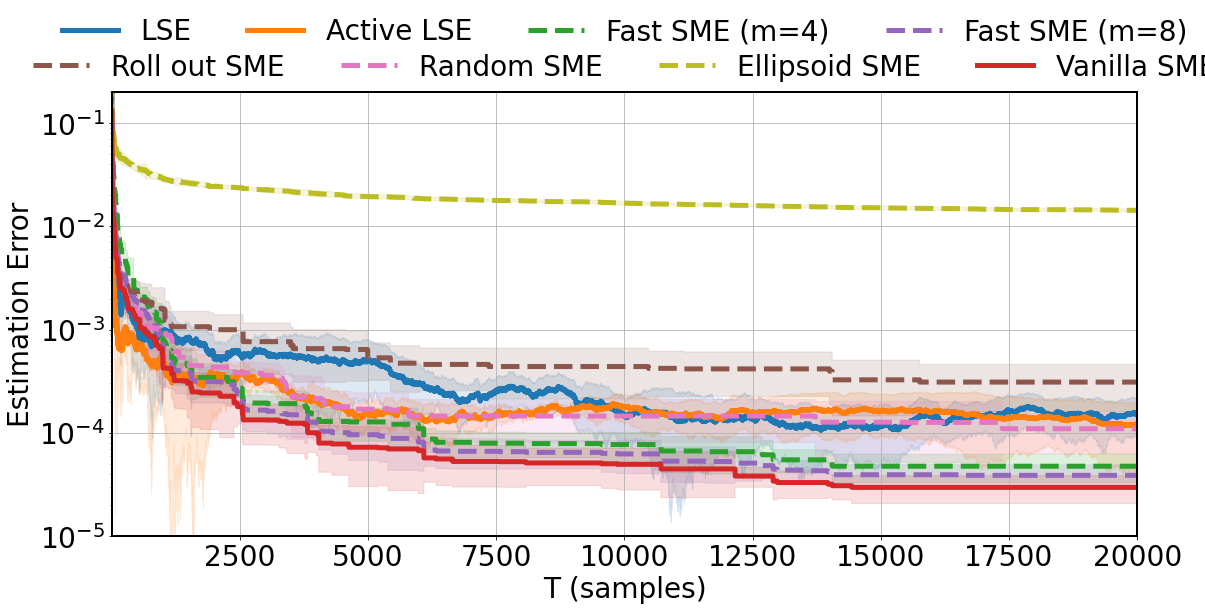

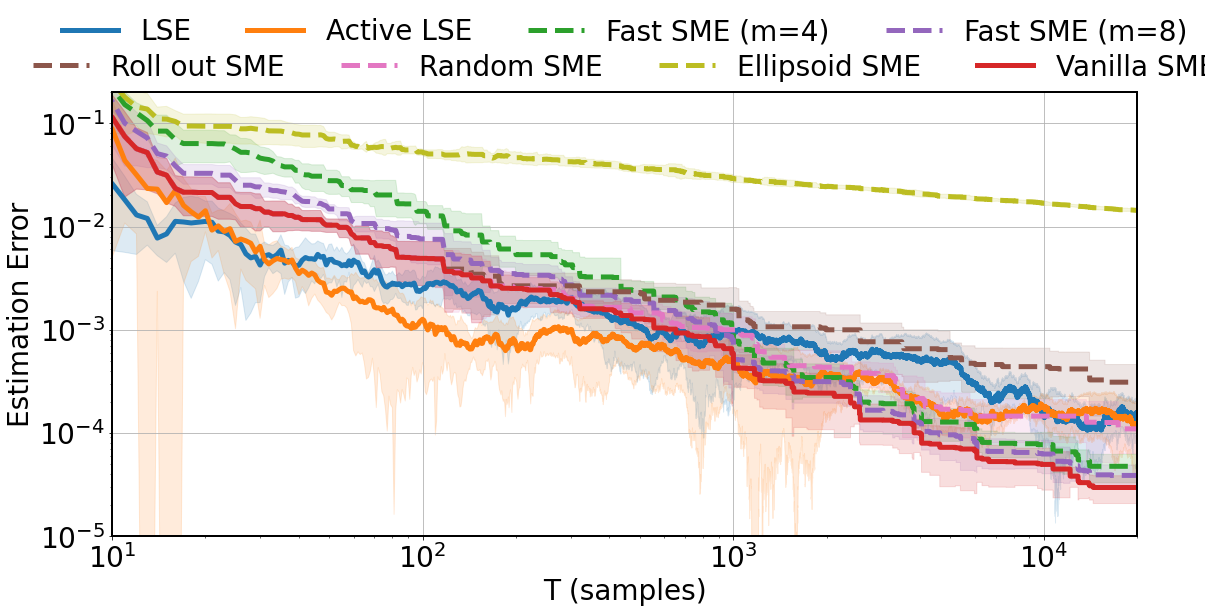

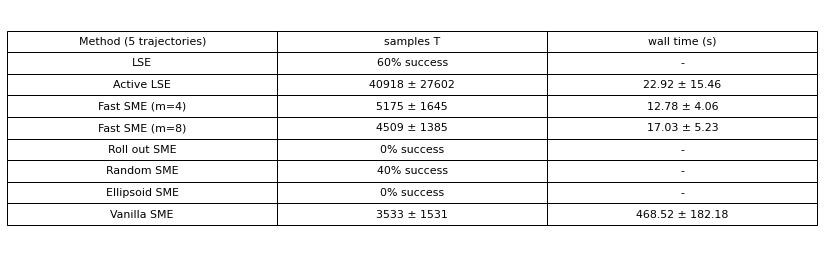

In [18]:
# Match pendulum_SME_plot.ipynb panels 1 & 2 combined (two thirds of the 26 x 6 figure).
PAPER_TWO_PANEL_FIGSIZE = (16, 8)
SMALL_SIZE = 28
BIGGER_SIZE = 28
LEGEND_SIZE = 28

plt.rc("font", size=BIGGER_SIZE)
plt.rc("axes", titlesize=BIGGER_SIZE)
plt.rc("axes", labelsize=BIGGER_SIZE)
plt.rc("xtick", labelsize=SMALL_SIZE)
plt.rc("ytick", labelsize=SMALL_SIZE)
plt.rc("legend", fontsize=LEGEND_SIZE)
plt.rc("figure", titlesize=BIGGER_SIZE)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 2

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

PAPER_SAVE_KWARGS = dict(
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.02,
    facecolor="white",
    edgecolor="none",
    transparent=False,
)

PAPER_SUBPLOT_ADJUST = dict(left=0.10, right=0.99, bottom=0.13, top=0.90)


def _prepare_figure_for_paper(fig) -> None:
    from matplotlib.legend import Legend

    fig.patch.set_facecolor("white")
    for ax in fig.axes:
        if not ax.axison:
            continue
        ax.set_facecolor("white")
        ax.tick_params(colors="black", labelcolor="black")
        ax.xaxis.label.set_color("black")
        ax.yaxis.label.set_color("black")
        ax.title.set_color("black")
    for legend in fig.findobj(Legend):
        for text in legend.get_texts():
            text.set_color("black")


def _add_two_row_legend(ax, *, n_first_row: int = 4):
    """Legend flush above axes with the first methods on row 1."""
    handles, labels = ax.get_legend_handles_labels()
    first_handles = handles[:n_first_row]
    first_labels = labels[:n_first_row]
    second_handles = handles[n_first_row:]
    second_labels = labels[n_first_row:]

    leg_bottom = ax.legend(
        second_handles,
        second_labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.0),
        ncol=len(second_handles),
        frameon=False,
        borderaxespad=0.0,
    )
    ax.add_artist(leg_bottom)
    leg_top = ax.legend(
        first_handles,
        first_labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.08),
        ncol=len(first_handles),
        frameon=False,
        borderaxespad=0.0,
    )
    return leg_top, leg_bottom


def _save_compact_figure(fig, path, *, extra_artists=()) -> None:
    fig.subplots_adjust(**PAPER_SUBPLOT_ADJUST)
    _prepare_figure_for_paper(fig)
    save_kwargs = dict(PAPER_SAVE_KWARGS)
    if extra_artists:
        save_kwargs["bbox_extra_artists"] = extra_artists
    fig.savefig(path, **save_kwargs)

linewidth_ = 5.0
alpha_band = 0.15
errorbar_markersize = 10
errorbar_capsize = 5
min_positive = 1e-12

err_ylabel = "Estimation Error"


def _finite_curve(y, std=None):
    y = np.asarray(y, dtype=float)
    x = np.arange(1, len(y) + 1)
    mask = np.isfinite(y)
    if std is None:
        return x[mask], y[mask], None, None
    std = np.asarray(std, dtype=float)
    lo = np.maximum(y - std, min_positive)
    hi = np.maximum(y + std, min_positive)
    return x[mask], y[mask], lo[mask], hi[mask]


def _plot_curve(ax, y, std, *, color, label, ls="-"):
    x, yy, lo, hi = _finite_curve(y, std)
    if len(x) == 0:
        return
    ax.plot(x, yy, color=color, lw=linewidth_, ls=ls, label=label)
    ax.fill_between(x, lo, hi, color=color, alpha=alpha_band)


def _format_T(T):
    if T is None or not np.isfinite(T):
        return "not reached"
    return f"{T:.0f}"


def _format_time(seconds):
    if seconds is None or not np.isfinite(seconds):
        return "-"
    return f"{seconds:.2f}"


def _plot_sme_width(
    ax,
    mean_curve,
    std_curve,
    reach_T_mean,
    *,
    color,
    label,
    ls="-",
    truncate_at_reach=True,
):
    sme_x, sme_y, sme_lo, sme_hi = _finite_curve(mean_curve, std_curve)
    if truncate_at_reach and np.isfinite(reach_T_mean):
        keep = sme_x <= np.floor(reach_T_mean)
        sme_x, sme_y, sme_lo, sme_hi = sme_x[keep], sme_y[keep], sme_lo[keep], sme_hi[keep]
        line_x = np.append(sme_x, reach_T_mean)
        line_y = np.append(sme_y, precision_tol)
    else:
        line_x, line_y = sme_x, sme_y
    if len(line_x) > 0:
        ax.plot(line_x, line_y, color=color, lw=linewidth_, ls=ls, label=label)
    if len(sme_x) > 0:
        ax.fill_between(sme_x, sme_lo, sme_hi, color=color, alpha=alpha_band)


# Distinct colors (avoid light yellow / pink-red clash).
COLOR_LSE = "#0072B2"
COLOR_ACTIVE = "#E69F00"
COLOR_TEMPLATE = ["#009E73", "#A6761D", "#8C6BB1", "#66C2A5"]
COLOR_ROLL = "#CC79A7"
COLOR_RANDOM = "#332288"
COLOR_ELLIPSOID = "#8C564B"
COLOR_VANILLA = "#D62728"


def _plot_estimation_error(
    ax, *, log_x: bool, log_y: bool, xlim_left: float, xlim_right: float
) -> None:
    _plot_curve(
        ax,
        mean_err_passive,
        std_err_passive,
        color=COLOR_LSE,
        label="LSE",
    )
    _plot_curve(
        ax,
        mean_err_active,
        std_err_active,
        color=COLOR_ACTIVE,
        label="Active LSE",
    )
    approx_ls = "--"
    for idx, n_sides in enumerate(sme_template_sides_list):
        summary = template_sme_summaries[n_sides]
        _plot_sme_width(
            ax,
            summary.mean_width_norm,
            summary.std_width_norm,
            summary.reach_T_mean,
            color=COLOR_TEMPLATE[idx % len(COLOR_TEMPLATE)],
            label=f"Fast SME (m={n_sides})",
            ls=approx_ls,
            truncate_at_reach=sme_stop_at_precision,
        )
    _plot_sme_width(
        ax,
        mean_width_roll_out_norm,
        std_width_roll_out_norm,
        roll_out_sme_reach_T_mean,
        color=COLOR_ROLL,
        # label=f"Roll out SME (H={int(sme_roll_out_recent_window)})",
        label=f"Roll out SME",
        ls=approx_ls,
        truncate_at_reach=sme_stop_at_precision,
    )
    _plot_sme_width(
        ax,
        mean_width_random_norm,
        std_width_random_norm,
        random_sme_reach_T_mean,
        color=COLOR_RANDOM,
        label=f"Random SME",
        ls=approx_ls,
        truncate_at_reach=sme_stop_at_precision,
    )
    _plot_sme_width(
        ax,
        mean_width_ellipsoid_norm,
        std_width_ellipsoid_norm,
        ellipsoid_sme_reach_T_mean,
        color=COLOR_ELLIPSOID,
        label="Ellipsoid SME",
        ls=approx_ls,
        truncate_at_reach=sme_stop_at_precision,
    )
    _plot_sme_width(
        ax,
        mean_width_passive_norm,
        std_width_passive_norm,
        sme_reach_T_mean,
        color=COLOR_VANILLA,
        label="Vanilla SME",
        ls="-",
        truncate_at_reach=sme_stop_at_precision,
    )
    ax.set_xlabel("T (samples)")
    ax.set_ylabel(err_ylabel)
    if log_x:
        ax.set_xscale("log")
    if log_y:
        ax.set_yscale("log")
    ax.set_xlim(left=xlim_left, right=xlim_right)
    ax.set_ylim(bottom=1e-5, top=2e-1)


plot_xlim_left = 10
plot_xlim_right = 2e4    #sme_horizon_T

fig1, ax1 = plt.subplots(figsize=PAPER_TWO_PANEL_FIGSIZE)
_plot_estimation_error(
    ax1,
    log_x=False,
    log_y=True,
    xlim_left=plot_xlim_left,
    xlim_right=plot_xlim_right,
)
legend_artists = _add_two_row_legend(ax1, n_first_row=4)
_save_compact_figure(
    fig1,
    FIGURES_DIR / "estimation_error_vs_samples.pdf",
    extra_artists=legend_artists,
)
plt.show()

fig1_loglog, ax1_loglog = plt.subplots(figsize=PAPER_TWO_PANEL_FIGSIZE)
_plot_estimation_error(
    ax1_loglog,
    log_x=True,
    log_y=True,
    xlim_left=plot_xlim_left,
    xlim_right=plot_xlim_right,
)
legend_artists_loglog = _add_two_row_legend(ax1_loglog, n_first_row=4)
_save_compact_figure(
    fig1_loglog,
    FIGURES_DIR / "estimation_error_vs_samples_loglog.pdf",
    extra_artists=legend_artists_loglog,
)
plt.show()

def _finite_mean_std(values):
    finite = np.asarray(
        [v for v in values if v is not None and np.isfinite(v)],
        dtype=float,
    )
    if finite.size == 0:
        return np.nan, np.nan
    return float(np.mean(finite)), float(np.std(finite))


def _format_mean_std(values, decimals, *, empty="not reached"):
    mean, std = _finite_mean_std(values)
    if not np.isfinite(mean):
        return empty
    return f"{mean:.{decimals}f} ± {std:.{decimals}f}"


def _format_success_rate(n_reached, n_total):
    if n_total <= 0:
        return "0% success"
    rate = 100.0 * float(n_reached) / float(n_total)
    return f"{rate:g}% success"


def _format_threshold_metrics(T_values, wall_values):
    n_total = len(T_values)
    n_reached = sum(
        T is not None and np.isfinite(T)
        for T in T_values
    )
    if n_total > 0 and n_reached == n_total:
        return (
            _format_mean_std(T_values, 0),
            _format_mean_std(wall_values, 2, empty="-"),
        )
    return _format_success_rate(n_reached, n_total), "-"


def _stable_T_values(curves):
    return [first_stable_under(curve, precision_tol) for curve in curves]


def _rls_wall_values(T_values, collect_wall_values, method_wall_values):
    return [
        (float(c_wall) + float(m_wall)) * float(T) / max_time_hor
        for T, c_wall, m_wall in zip(T_values, collect_wall_values, method_wall_values)
        if T is not None and np.isfinite(T)
    ]


def _sme_wall_values(T_values, method_wall_values):
    values = []
    for T, collect_wall, method_wall in zip(
        T_values,
        passive_collect_wall_list[:n_epoch_sme],
        method_wall_values,
    ):
        if T is None or not np.isfinite(T):
            continue
        collect_to_T = float(collect_wall) * float(T) / max_time_hor
        if sme_stop_at_precision:
            method_to_T = float(method_wall)
        else:
            method_to_T = float(method_wall) * float(T) / float(sme_eval_max_T)
        values.append(collect_to_T + method_to_T)
    return values


passive_rls_stable_T_values = _stable_T_values(passive_rls_err_seqs)
active_rls_stable_T_values = _stable_T_values(active_rls_err_seqs)
active_collect_wall_ok_values = [
    res.collection_wall_s for res in res_active_list if not res.planning_failed
]
passive_rls_stable_wall_values = _rls_wall_values(
    passive_rls_stable_T_values,
    passive_collect_wall_list,
    passive_rls_wall_list,
)
active_rls_stable_wall_values = _rls_wall_values(
    active_rls_stable_T_values,
    active_collect_wall_ok_values,
    active_rls_wall_list,
)

template_sme_reach_wall_values = {
    n_sides: _sme_wall_values(summary.reach_T, summary.wall_s_by_traj)
    for n_sides, summary in template_sme_summaries.items()
}
pd_sme_reach_wall_values = _sme_wall_values(passive_sme_reach_T, passive_sme_wall_list)
ellipsoid_sme_reach_wall_values = _sme_wall_values(
    ellipsoid_sme_reach_T,
    ellipsoid_sme_wall_list,
)
roll_out_sme_reach_wall_values = _sme_wall_values(
    roll_out_sme_reach_T,
    roll_out_sme_wall_list,
)
random_sme_reach_wall_values = _sme_wall_values(
    random_sme_reach_T,
    random_sme_wall_list,
)

threshold_table_rows = [
    [
        "LSE",
        *_format_threshold_metrics(
            passive_rls_stable_T_values,
            passive_rls_stable_wall_values,
        ),
    ],
    [
        "Active LSE",
        *_format_threshold_metrics(
            active_rls_stable_T_values,
            active_rls_stable_wall_values,
        ),
    ],
]

for n_sides in sme_template_sides_list:
    summary = template_sme_summaries[n_sides]
    threshold_table_rows.append(
        [
            f"Fast SME (m={n_sides})",
            *_format_threshold_metrics(
                summary.reach_T,
                template_sme_reach_wall_values[n_sides],
            ),
        ]
    )

threshold_table_rows.append(
    [
        f"Roll out SME",
        *_format_threshold_metrics(
            roll_out_sme_reach_T,
            roll_out_sme_reach_wall_values,
        ),
    ]
)

threshold_table_rows.append(
    [
        f"Random SME",
        *_format_threshold_metrics(
            random_sme_reach_T,
            random_sme_reach_wall_values,
        ),
    ]
)

threshold_table_rows.append(
    [
        "Ellipsoid SME",
        *_format_threshold_metrics(
            ellipsoid_sme_reach_T,
            ellipsoid_sme_reach_wall_values,
        ),
    ]
)

threshold_table_rows.append(
    [
        "Vanilla SME",
        *_format_threshold_metrics(
            passive_sme_reach_T,
            pd_sme_reach_wall_values,
        ),
    ]
)

fig2, ax2 = plt.subplots(figsize=(12.0, 4.2))
ax2.axis("off")
threshold_tbl = ax2.table(
    cellText=threshold_table_rows,
    colLabels=[f"Method ({n_epoch_sme} trajectories)", "samples T", "wall time (s)"],
    loc="center",
    cellLoc="center",
)
threshold_tbl.auto_set_font_size(False)
threshold_tbl.set_fontsize(11)
threshold_tbl.scale(1.1, 1.7)
fig2.tight_layout()
_prepare_figure_for_paper(fig2)
fig2.savefig(FIGURES_DIR / "precision_threshold_table_full.png", **PAPER_SAVE_KWARGS)
plt.show()

## 6) Save results for reload and plotting

This writes the collected data, fitted error curves, SME summaries, LSE P-matrix sequences, plotting settings, and threshold table inputs to a pickle file. Reload this file later to recreate the plots without rerunning data collection or estimation.

In [12]:
results_path = Path("pendulum_LSE_active_results.pkl")

plot_reload_data = {
    "config": {
        "disturbance": disturbance,
        "parameter_dist": parameter_dist,
        "mult_w": mult_w,
        "c_input": c_input,
        "parameter_input": parameter_input,
        "mult_u": mult_u,
        "n_epoch": n_epoch,
        "n_epoch_sme": n_epoch_sme,
        "n_epoch_a": n_epoch_a,
        "max_time_hor": max_time_hor,
        "precision_tol": precision_tol,
        "w_max": w_max,
        "sme_min_T": sme_min_T,
        "sme_run_mode": sme_run_mode,
        "sme_solver": sme_solver,
        "sme_ellipsoid_objective": sme_ellipsoid_objective,
        "sme_horizon_T": sme_horizon_T,
        "sme_eval_max_T": sme_eval_max_T,
        "sme_template_sides_list": list(sme_template_sides_list),
        "sme_roll_out_recent_window": sme_roll_out_recent_window,
        "sme_random_sample_size": sme_random_sample_size,
        "sme_random_seed": sme_random_seed,
        "update_every": update_every,
        "plot_xlim_left": plot_xlim_left,
        "plot_xlim_right": plot_xlim_right,
        "plot_ylim": (1e-5, 1e-2),
        "p_matrix_ridge": p_matrix_ridge,
    },
    "theta_star": theta_star,
    "passive_data": {
        "Delta_S_list": Delta_S_list,
        "Phi_S_U_list": Phi_S_U_list,
        "collect_wall_list": passive_collect_wall_list,
        "collect_wall_s": passive_collect_wall_s,
    },
    "active_results": {
        "res_active_list": res_active_list,
        "collect_wall_list": active_collect_wall_list,
        "collect_wall_s": active_collect_wall_s,
    },
    "rls": {
        "passive_err_seqs": passive_rls_err_seqs,
        "active_err_seqs": active_rls_err_seqs,
        "mean_err_passive": mean_err_passive,
        "std_err_passive": std_err_passive,
        "mean_err_active": mean_err_active,
        "std_err_active": std_err_active,
        "passive_wall_list": passive_rls_wall_list,
        "active_wall_list": active_rls_wall_list,
        "passive_stable_T_values": passive_rls_stable_T_values,
        "active_stable_T_values": active_rls_stable_T_values,
        "passive_stable_wall_values": passive_rls_stable_wall_values,
        "active_stable_wall_values": active_rls_stable_wall_values,
        "passive_p_matrix_seqs": passive_rls_p_matrix_seqs,
        "active_p_matrix_seqs": active_rls_p_matrix_seqs,
    },
    "sme": {
        "exact_summary": exact_sme_summary,
        "template_summaries": template_sme_summaries,
        "roll_out_summary": roll_out_sme_summary,
        "random_summary": random_sme_summary,
        "ellipsoid_summary": ellipsoid_sme_summary,
        "template_reach_wall_values": template_sme_reach_wall_values,
        "roll_out_reach_wall_values": roll_out_sme_reach_wall_values,
        "random_reach_wall_values": random_sme_reach_wall_values,
        "ellipsoid_reach_wall_values": ellipsoid_sme_reach_wall_values,
        "exact_reach_wall_values": pd_sme_reach_wall_values,
    },
    "threshold_table_rows": threshold_table_rows,
}

with results_path.open("wb") as f:
    pickle.dump(plot_reload_data, f)

print(f"Saved reload/plot data to {results_path.resolve()}")

Saved reload/plot data to C:\Research\Cursor_dir\real-analytic-nonlinear-sys-id-main\pendulum sys id\pendulum_LSE_active_results.pkl


C:\Users\82734\AppData\Local\Temp/ipykernel_2972/2480654965.py:122: RuntimeWarning: Mean of empty slice
  means.append(np.nanmean(hits))
c:\Users\82734\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\lib\_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


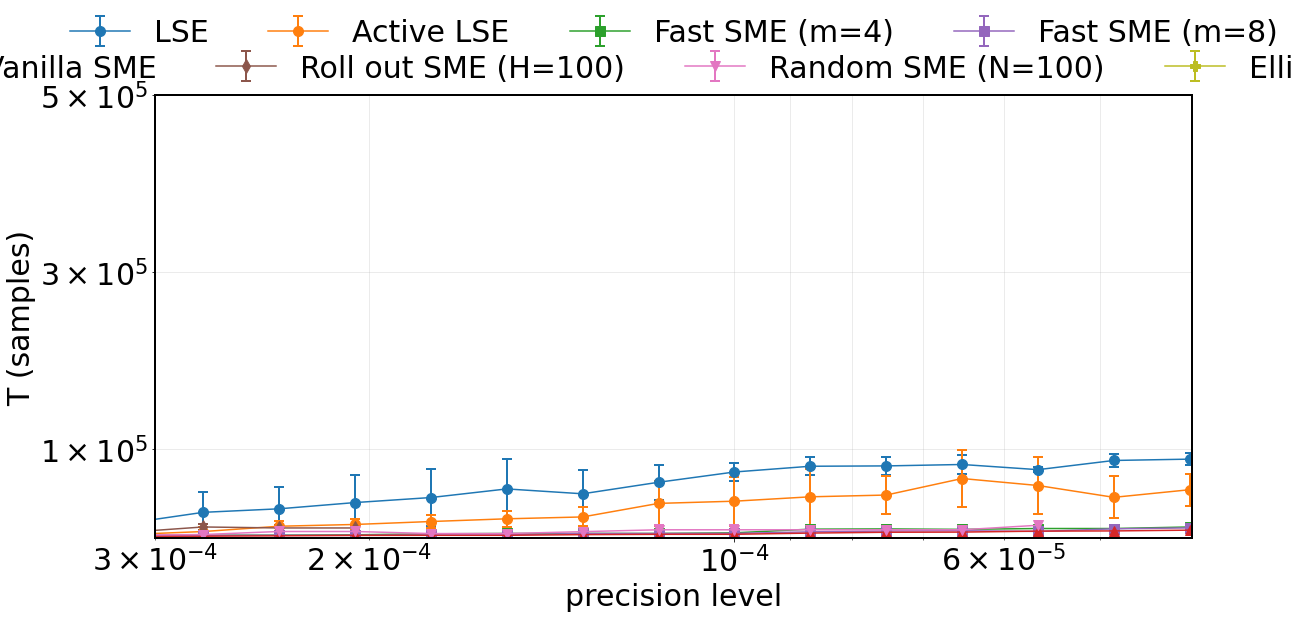

Saved figures to: C:\Research\Cursor_dir\real-analytic-nonlinear-sys-id-main\pendulum sys id\figures


In [13]:
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Match pendulum_SME_plot.ipynb panels 1 & 2 combined (two thirds of the 26 x 6 figure).
PAPER_TWO_PANEL_FIGSIZE = (18, 8)
SMALL_SIZE = 30
BIGGER_SIZE = 30
LEGEND_SIZE = 30

plt.rc("font", size=BIGGER_SIZE)
plt.rc("axes", titlesize=BIGGER_SIZE)
plt.rc("axes", labelsize=BIGGER_SIZE)
plt.rc("xtick", labelsize=SMALL_SIZE)
plt.rc("ytick", labelsize=SMALL_SIZE)
plt.rc("legend", fontsize=LEGEND_SIZE)
plt.rc("figure", titlesize=BIGGER_SIZE)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 2

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

PAPER_SAVE_KWARGS = dict(
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.02,
    facecolor="white",
    edgecolor="none",
    transparent=False,
)

PAPER_SUBPLOT_ADJUST = dict(left=0.10, right=0.90, bottom=0.13, top=0.90)


def _prepare_figure_for_paper(fig) -> None:
    from matplotlib.legend import Legend

    fig.patch.set_facecolor("white")
    for ax in fig.axes:
        if not ax.axison:
            continue
        ax.set_facecolor("white")
        ax.tick_params(colors="black", labelcolor="black")
        ax.xaxis.label.set_color("black")
        ax.yaxis.label.set_color("black")
        ax.title.set_color("black")
    for legend in fig.findobj(Legend):
        for text in legend.get_texts():
            text.set_color("black")


from matplotlib.ticker import FixedLocator, NullLocator

def _add_two_row_legend(ax, *, n_first_row: int = 4):
    """Legend flush above axes with the first methods on row 1."""
    handles, labels = ax.get_legend_handles_labels()
    first_handles = handles[:n_first_row]
    first_labels = labels[:n_first_row]
    second_handles = handles[n_first_row:]
    second_labels = labels[n_first_row:]

    leg_bottom = ax.legend(
        second_handles,
        second_labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.0),
        ncol=len(second_handles),
        frameon=False,
        borderaxespad=0.0,
    )
    ax.add_artist(leg_bottom)
    leg_top = ax.legend(
        first_handles,
        first_labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.08),
        ncol=len(first_handles),
        frameon=False,
        borderaxespad=0.0,
    )
    return leg_top, leg_bottom


def _save_compact_figure(fig, path, *, extra_artists=()) -> None:
    fig.subplots_adjust(**PAPER_SUBPLOT_ADJUST)
    _prepare_figure_for_paper(fig)
    save_kwargs = dict(PAPER_SAVE_KWARGS)
    if extra_artists:
        save_kwargs["bbox_extra_artists"] = extra_artists
    fig.savefig(path, **save_kwargs)

results_path = "pendulum_LSE_active_results.pkl"

with open(results_path, "rb") as f:
    data = pickle.load(f)

rls = data["rls"]
sme = data["sme"]

precision_levels = np.logspace(-3, -4.5, 25)

def first_stable_under(curve, tol):
    values = np.asarray(curve, dtype=float)
    ok = np.isfinite(values) & (values <= tol)
    suffix_ok = np.logical_and.accumulate(ok[::-1])[::-1]
    idx = np.where(suffix_ok)[0]
    return np.nan if idx.size == 0 else int(idx[0]) + 1

def first_hit(curve, tol):
    values = np.asarray(curve, dtype=float)
    idx = np.where(np.isfinite(values) & (values <= tol))[0]
    return np.nan if idx.size == 0 else int(idx[0]) + 1

def mean_std_hit_times(curves, levels, hit_fn):
    means, stds = [], []
    for tol in levels:
        hits = np.array([hit_fn(curve, tol) for curve in curves], dtype=float)
        means.append(np.nanmean(hits))
        stds.append(np.nanstd(hits))
    return np.array(means), np.array(stds)

pd_rls_mean, pd_rls_std = mean_std_hit_times(
    rls["passive_err_seqs"],
    precision_levels,
    first_stable_under,
)

active_rls_mean, active_rls_std = mean_std_hit_times(
    rls["active_err_seqs"],
    precision_levels,
    first_stable_under,
)

template_hit_series = []
for m, summary in sme["template_summaries"].items():
    mean_hit, std_hit = mean_std_hit_times(
        summary.width_norm_seqs,
        precision_levels,
        first_hit,
    )
    template_hit_series.append((m, mean_hit, std_hit))

exact_summary = sme["exact_summary"]
exact_sme_mean, exact_sme_std = mean_std_hit_times(
    exact_summary.width_norm_seqs,
    precision_levels,
    first_hit,
)

roll_out_summary = sme.get("roll_out_summary", sme.get("fixed_sample_summary"))
if roll_out_summary is not None:
    roll_out_sme_mean, roll_out_sme_std = mean_std_hit_times(
        roll_out_summary.width_norm_seqs,
        precision_levels,
        first_hit,
    )
else:
    roll_out_sme_mean = roll_out_sme_std = None

random_summary = sme.get("random_summary")
if random_summary is not None:
    random_sme_mean, random_sme_std = mean_std_hit_times(
        random_summary.width_norm_seqs,
        precision_levels,
        first_hit,
    )
else:
    random_sme_mean = random_sme_std = None

ellipsoid_summary = sme.get("trace_ellipsoid_summary", sme.get("ellipsoid_summary"))
if ellipsoid_summary is not None:
    ellipsoid_sme_mean, ellipsoid_sme_std = mean_std_hit_times(
        ellipsoid_summary.width_norm_seqs,
        precision_levels,
        first_hit,
    )
else:
    ellipsoid_sme_mean = ellipsoid_sme_std = None


PRECISION_YTICK_VALUES = [1e5, 3e5, 5e5]
PRECISION_YTICK_LABELS = [r"$1 \times 10^{5}$", r"$3 \times 10^{5}$", r"$5 \times 10^{5}$"]
template_colors = ["C2", "C4", "C5", "C6", "C7", "C8", "C9"]


def _set_precision_yticks(ax):
    """Semi-log panel: linear y in samples with full-scale tick labels."""
    ax.set_yscale("linear")
    ax.set_yticks(PRECISION_YTICK_VALUES)
    ax.set_yticklabels(PRECISION_YTICK_LABELS)
    ax.yaxis.set_minor_locator(NullLocator())


def _plot_hit_time_panel(ax):
    errorbar_kw = dict(capsize=5, markersize=10, elinewidth=2, capthick=2)
    ax.errorbar(
        precision_levels,
        pd_rls_mean,
        yerr=pd_rls_std,
        label="LSE",
        color="C0",
        marker="o",
        **errorbar_kw,
    )
    ax.errorbar(
        precision_levels,
        active_rls_mean,
        yerr=active_rls_std,
        label="Active LSE",
        color="C1",
        marker="o",
        **errorbar_kw,
    )
    for idx, (m, mean_hit, std_hit) in enumerate(template_hit_series):
        ax.errorbar(
            precision_levels,
            mean_hit,
            yerr=std_hit,
            label=f"Fast SME (m={m})",
            color=template_colors[idx % len(template_colors)],
            marker="s",
            **errorbar_kw,
        )
    ax.errorbar(
        precision_levels,
        exact_sme_mean,
        yerr=exact_sme_std,
        label="Vanilla SME",
        color="C3",
        marker="^",
        **errorbar_kw,
    )
    if roll_out_sme_mean is not None:
        config = data.get("config", {})
        roll_h = int(
            config.get("sme_roll_out_recent_window", config.get("sme_fixed_recent_window", 0))
        )
        ax.errorbar(
            precision_levels,
            roll_out_sme_mean,
            yerr=roll_out_sme_std,
            label=f"Roll out SME (H={roll_h})" if roll_h else "Roll out SME",
            color="C5",
            marker="d",
            **errorbar_kw,
        )
    if random_sme_mean is not None:
        random_n = int(data.get("config", {}).get("sme_random_sample_size", 0))
        ax.errorbar(
            precision_levels,
            random_sme_mean,
            yerr=random_sme_std,
            label=f"Random SME (N={random_n})" if random_n else "Random SME",
            color="C6",
            marker="v",
            **errorbar_kw,
        )
    if ellipsoid_sme_mean is not None:
        ax.errorbar(
            precision_levels,
            ellipsoid_sme_mean,
            yerr=ellipsoid_sme_std,
            label="Ellipsoid SME",
            color="C8",
            marker="P",
            **errorbar_kw,
        )

    ax.set_xscale("log")
    _set_precision_yticks(ax)
    ax.set_xlim(3e-4, 4.2e-5)    #  ax.set_xlim(1e-3, 8.5e-5)
    ax.set_ylim(-1e3, 5e5)
    ax.set_ylabel("T (samples)")
    ax.grid(True, which="both", alpha=0.3)


# # Log-log version (log x, log y) — disabled; using semi-log only.
# fig_log, ax_log = plt.subplots(figsize=PAPER_TWO_PANEL_FIGSIZE)
# _plot_hit_time_panel(ax_log)
# ax_log.set_yscale("log")
# ax_log.yaxis.set_major_locator(FixedLocator(PRECISION_YTICK_VALUES))
# ax_log.set_yticklabels(PRECISION_YTICK_LABELS)
# ax_log.set_xlabel("precision level")
# _add_two_row_legend(fig_log, ax_log, n_first_row=2)
# fig_log.tight_layout(rect=[0, 0, 1, 0.82])
# _prepare_figure_for_paper(fig_log)
# fig_log.savefig(
#     FIGURES_DIR / "hit_time_vs_precision_log_samples.png",
#     **PAPER_SAVE_KWARGS,
# )
# plt.show()

fig_lin, ax_lin = plt.subplots(figsize=PAPER_TWO_PANEL_FIGSIZE)
_plot_hit_time_panel(ax_lin)
ax_lin.set_xlabel("precision level")
legend_artists = _add_two_row_legend(ax_lin, n_first_row=4)
_save_compact_figure(
    fig_lin,
    FIGURES_DIR / "hit_time_vs_precision_linear_samples.png",
    extra_artists=legend_artists,
)
plt.show()

print("Saved figures to:", FIGURES_DIR.resolve())

## 7) Reload and plot estimation error (paper labels)

Reload `pendulum_LSE_active_results.pkl` and recreate the estimation-error figure with paper-facing names: keep only Fast SME ($m=8$) as **Our Proposed ALG**, and rename roll-out / random SME to Rolling / Random History SME.


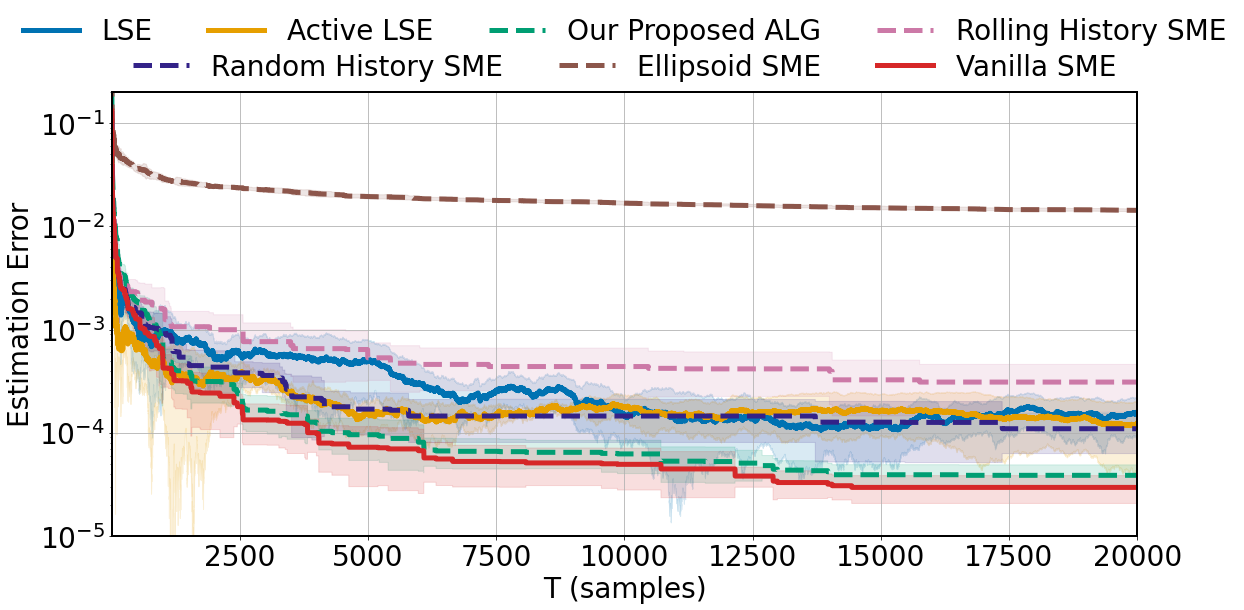

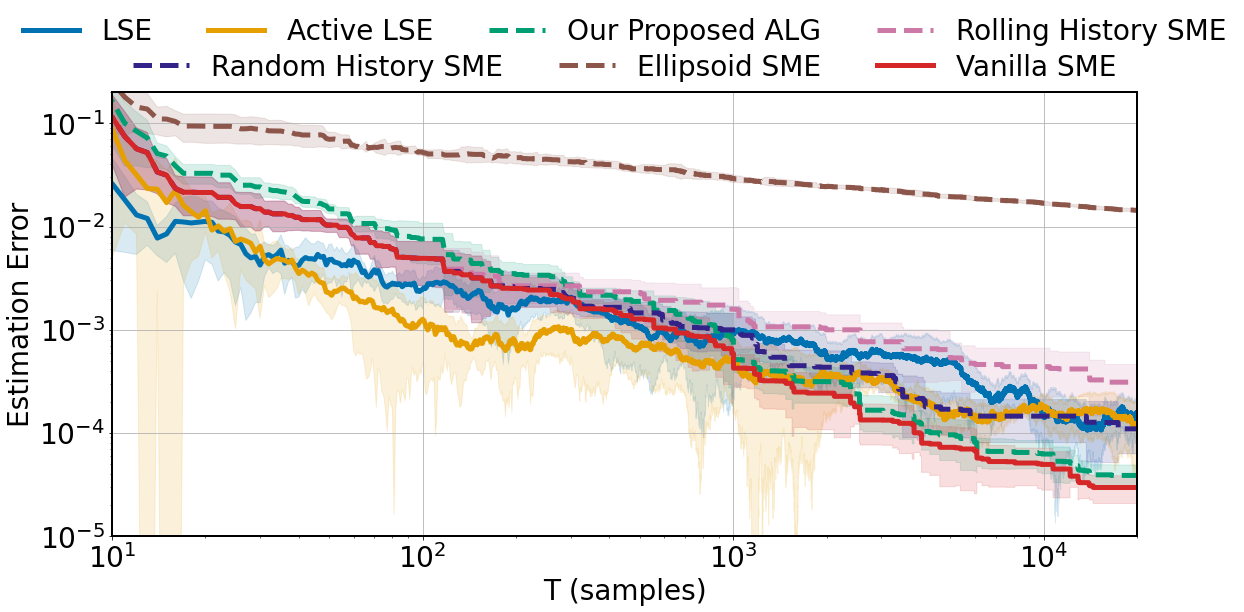

Saved paper-label estimation-error figures to: C:\Research\Cursor_dir\yingying\figures


In [6]:
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Match pendulum_SME_plot.ipynb panels 1 & 2 combined (two thirds of the 26 x 6 figure).
PAPER_TWO_PANEL_FIGSIZE = (16, 8)
SMALL_SIZE = 28
BIGGER_SIZE = 28
LEGEND_SIZE = 28

plt.rc("font", size=BIGGER_SIZE)
plt.rc("axes", titlesize=BIGGER_SIZE)
plt.rc("axes", labelsize=BIGGER_SIZE)
plt.rc("xtick", labelsize=SMALL_SIZE)
plt.rc("ytick", labelsize=SMALL_SIZE)
plt.rc("legend", fontsize=LEGEND_SIZE)
plt.rc("figure", titlesize=BIGGER_SIZE)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 2

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

PAPER_SAVE_KWARGS = dict(
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.02,
    facecolor="white",
    edgecolor="none",
    transparent=False,
)

PAPER_SUBPLOT_ADJUST = dict(left=0.10, right=0.99, bottom=0.13, top=0.90)


def _prepare_figure_for_paper(fig) -> None:
    from matplotlib.legend import Legend

    fig.patch.set_facecolor("white")
    for ax in fig.axes:
        if not ax.axison:
            continue
        ax.set_facecolor("white")
        ax.tick_params(colors="black", labelcolor="black")
        ax.xaxis.label.set_color("black")
        ax.yaxis.label.set_color("black")
        ax.title.set_color("black")
    for legend in fig.findobj(Legend):
        for text in legend.get_texts():
            text.set_color("black")


def _add_two_row_legend(ax, *, n_first_row: int = 4):
    """Legend flush above axes with the first methods on row 1."""
    handles, labels = ax.get_legend_handles_labels()
    first_handles = handles[:n_first_row]
    first_labels = labels[:n_first_row]
    second_handles = handles[n_first_row:]
    second_labels = labels[n_first_row:]

    leg_bottom = ax.legend(
        second_handles,
        second_labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.0),
        ncol=max(len(second_handles), 1),
        frameon=False,
        borderaxespad=0.0,
    )
    ax.add_artist(leg_bottom)
    leg_top = ax.legend(
        first_handles,
        first_labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.08),
        ncol=max(len(first_handles), 1),
        frameon=False,
        borderaxespad=0.0,
    )
    return leg_top, leg_bottom


def _save_compact_figure(fig, path, *, extra_artists=()) -> None:
    fig.subplots_adjust(**PAPER_SUBPLOT_ADJUST)
    _prepare_figure_for_paper(fig)
    save_kwargs = dict(PAPER_SAVE_KWARGS)
    if extra_artists:
        save_kwargs["bbox_extra_artists"] = extra_artists
    fig.savefig(path, **save_kwargs)


results_path = Path("pendulum_LSE_active_results.pkl")
with results_path.open("rb") as f:
    data = pickle.load(f)

cfg = data["config"]
rls = data["rls"]
sme = data["sme"]

precision_tol = float(cfg["precision_tol"])
sme_stop_at_precision = cfg.get("sme_run_mode") == "precision"
plot_xlim_left = float(cfg.get("plot_xlim_left", 10))
# Match the in-notebook estimation-error window (SME horizon), not full LSE horizon.
plot_xlim_right = 2e4

mean_err_passive = rls["mean_err_passive"]
std_err_passive = rls["std_err_passive"]
mean_err_active = rls["mean_err_active"]
std_err_active = rls["std_err_active"]

exact_summary = sme["exact_summary"]
template_summaries = sme["template_summaries"]
roll_out_summary = sme.get("roll_out_summary", sme.get("fixed_sample_summary"))
random_summary = sme.get("random_summary")
ellipsoid_summary = sme.get("trace_ellipsoid_summary", sme.get("ellipsoid_summary"))

# Paper labels: only Fast SME (m=8) as Our Proposed ALG.
proposed_m = 8
proposed_summary = template_summaries[proposed_m]

linewidth_ = 5.0
alpha_band = 0.15
min_positive = 1e-12
err_ylabel = "Estimation Error"


def _finite_curve(y, std=None):
    y = np.asarray(y, dtype=float)
    x = np.arange(1, len(y) + 1)
    mask = np.isfinite(y)
    if std is None:
        return x[mask], y[mask], None, None
    std = np.asarray(std, dtype=float)
    lo = np.maximum(y - std, min_positive)
    hi = np.maximum(y + std, min_positive)
    return x[mask], y[mask], lo[mask], hi[mask]


def _plot_curve(ax, y, std, *, color, label, ls="-"):
    x, yy, lo, hi = _finite_curve(y, std)
    if len(x) == 0:
        return
    ax.plot(x, yy, color=color, lw=linewidth_, ls=ls, label=label)
    ax.fill_between(x, lo, hi, color=color, alpha=alpha_band)


def _plot_sme_width(
    ax,
    mean_curve,
    std_curve,
    reach_T_mean,
    *,
    color,
    label,
    ls="-",
    truncate_at_reach=True,
):
    sme_x, sme_y, sme_lo, sme_hi = _finite_curve(mean_curve, std_curve)
    if truncate_at_reach and np.isfinite(reach_T_mean):
        keep = sme_x <= np.floor(reach_T_mean)
        sme_x, sme_y, sme_lo, sme_hi = sme_x[keep], sme_y[keep], sme_lo[keep], sme_hi[keep]
        line_x = np.append(sme_x, reach_T_mean)
        line_y = np.append(sme_y, precision_tol)
    else:
        line_x, line_y = sme_x, sme_y
    if len(line_x) > 0:
        ax.plot(line_x, line_y, color=color, lw=linewidth_, ls=ls, label=label)
    if len(sme_x) > 0:
        ax.fill_between(sme_x, sme_lo, sme_hi, color=color, alpha=alpha_band)


# Distinct paper colors (avoid light yellow / pink-red clash).
COLOR_LSE = "#0072B2"          # blue
COLOR_ACTIVE = "#E69F00"       # orange
COLOR_PROPOSED = "#009E73"     # bluish green
COLOR_ROLL = "#CC79A7"         # pink
COLOR_RANDOM = "#332288"       # dark indigo (was ellipsoid)
COLOR_ELLIPSOID = "#8C564B"    # brown
COLOR_VANILLA = "#D62728"      # red


def _plot_estimation_error_paper(
    ax, *, log_x: bool, log_y: bool, xlim_left: float, xlim_right: float
) -> None:
    approx_ls = "--"
    _plot_curve(ax, mean_err_passive, std_err_passive, color=COLOR_LSE, label="LSE")
    _plot_curve(ax, mean_err_active, std_err_active, color=COLOR_ACTIVE, label="Active LSE")
    _plot_sme_width(
        ax,
        proposed_summary.mean_width_norm,
        proposed_summary.std_width_norm,
        proposed_summary.reach_T_mean,
        color=COLOR_PROPOSED,
        label="Our Proposed ALG",
        ls=approx_ls,
        truncate_at_reach=sme_stop_at_precision,
    )
    if roll_out_summary is not None:
        _plot_sme_width(
            ax,
            roll_out_summary.mean_width_norm,
            roll_out_summary.std_width_norm,
            roll_out_summary.reach_T_mean,
            color=COLOR_ROLL,
            label="Rolling History SME",
            ls=approx_ls,
            truncate_at_reach=sme_stop_at_precision,
        )
    if random_summary is not None:
        _plot_sme_width(
            ax,
            random_summary.mean_width_norm,
            random_summary.std_width_norm,
            random_summary.reach_T_mean,
            color=COLOR_RANDOM,
            label="Random History SME",
            ls=approx_ls,
            truncate_at_reach=sme_stop_at_precision,
        )
    if ellipsoid_summary is not None:
        _plot_sme_width(
            ax,
            ellipsoid_summary.mean_width_norm,
            ellipsoid_summary.std_width_norm,
            ellipsoid_summary.reach_T_mean,
            color=COLOR_ELLIPSOID,
            label="Ellipsoid SME",
            ls=approx_ls,
            truncate_at_reach=sme_stop_at_precision,
        )
    _plot_sme_width(
        ax,
        exact_summary.mean_width_norm,
        exact_summary.std_width_norm,
        exact_summary.reach_T_mean,
        color=COLOR_VANILLA,
        label="Vanilla SME",
        ls="-",
        truncate_at_reach=sme_stop_at_precision,
    )
    ax.set_xlabel("T (samples)")
    ax.set_ylabel(err_ylabel)
    if log_x:
        ax.set_xscale("log")
    if log_y:
        ax.set_yscale("log")
    ax.set_xlim(left=xlim_left, right=xlim_right)
    ax.set_ylim(bottom=1e-5, top=2e-1)


fig_err, ax_err = plt.subplots(figsize=PAPER_TWO_PANEL_FIGSIZE)
_plot_estimation_error_paper(
    ax_err,
    log_x=False,
    log_y=True,
    xlim_left=plot_xlim_left,
    xlim_right=plot_xlim_right,
)
legend_artists = _add_two_row_legend(ax_err, n_first_row=4)
_save_compact_figure(
    fig_err,
    FIGURES_DIR / "estimation_error_vs_samples_paper.pdf",
    extra_artists=legend_artists,
)
plt.show()

fig_err_loglog, ax_err_loglog = plt.subplots(figsize=PAPER_TWO_PANEL_FIGSIZE)
_plot_estimation_error_paper(
    ax_err_loglog,
    log_x=True,
    log_y=True,
    xlim_left=plot_xlim_left,
    xlim_right=plot_xlim_right,
)
legend_artists_loglog = _add_two_row_legend(ax_err_loglog, n_first_row=4)
_save_compact_figure(
    fig_err_loglog,
    FIGURES_DIR / "estimation_error_vs_samples_loglog_paper.pdf",
    extra_artists=legend_artists_loglog,
)
plt.show()

print("Saved paper-label estimation-error figures to:", FIGURES_DIR.resolve())
